# IBM Quantum Hardware Feasibility — One-Qubit QSVM Kernel

This notebook contains the IBM Quantum hardware feasibility component of the dissertation’s diagnostic intervention. It should be read together with `QML_Healthcare_Simulator_Final.ipynb`, which remains the full diagnostic benchmark.

The hardware workflow does **not** retrain the ResNet feature extractor and does **not** run the complete BreaKHis QSVM kernel on quantum hardware. Instead, it loads the normalized scalar $\theta$ embeddings generated by the simulator pipeline, selects a balanced subset, builds one-qubit overlap circuits, estimates the quantum kernel on an IBM backend, compares the hardware kernel with the analytic one-qubit kernel, and evaluates a precomputed-kernel SVM on the subset.

The goal is hardware executability and kernel-noise characterization under NISQ constraints. The result should not be interpreted as full hardware diagnostic performance or as evidence of quantum advantage.

## Simulator artifact loaded by this notebook

The full simulator / analytic statevector-equivalent QSVM test metrics loaded from `qsvm_results.json` are:

| Metric | Value |
|---|---:|
| Accuracy | 0.8000 |
| Balanced accuracy | 0.7803 |
| Precision | 0.9051 |
| Recall / sensitivity | 0.8196 |
| Specificity | 0.7409 |
| F1-score | 0.8602 |
| MCC | 0.5196 |
| AUC-ROC | 0.8038 |

The simulator confusion matrix was:

$$
\begin{bmatrix}
286 & 100 \\
210 & 954
\end{bmatrix}
$$

## Hardware subset result retained for reporting

The retained IBM hardware result in this notebook corresponds to the previous successful balanced subset run:

| Setting | Value |
|---|---:|
| Train subset | 80 images: 40 benign + 40 malignant |
| Test subset | 80 images: 40 benign + 40 malignant |
| Shots | 128 |
| Total circuits | 9,562 |
| Total circuit-shots | 1,223,936 |
| Backend in stored output | `ibm_kingston` |
| Selected physical qubit in stored output | 10 |
| Maximum transpiled depth in stored output | 6 |

The retained subset comparison is:

| Model | Accuracy | Balanced accuracy | Precision | Recall | Specificity | F1-score | MCC | AUC-ROC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Analytic subset | 0.7625 | 0.7625 | 0.7561 | 0.7750 | 0.7500 | 0.7654 | 0.5252 | 0.7891 |
| Hardware raw | 0.7500 | 0.7500 | 0.7500 | 0.7500 | 0.7500 | 0.7500 | 0.5000 | 0.7922 |
| Hardware corrected | 0.7500 | 0.7500 | 0.7500 | 0.7500 | 0.7500 | 0.7500 | 0.5000 | 0.7922 |

The retained kernel-error summary is:

| Kernel comparison | Mean absolute error | Median absolute error | Maximum absolute error |
|---|---:|---:|---:|
| Train raw vs analytic | 0.0134 | 0.0081 | 0.1047 |
| Train corrected vs analytic | 0.0134 | 0.0081 | 0.1047 |
| Test raw vs analytic | 0.0137 | 0.0081 | 0.1148 |
| Test corrected vs analytic | 0.0137 | 0.0081 | 0.1148 |

Later aggressive hardware attempts that failed with IBM Runtime error `9701` or exceeded the available execution budget are not used as final dissertation results. They should be mentioned, at most, as operational limitations encountered during hardware execution.

## Cell 1 — Environment validation

This cell verifies the Python executable, Qiskit installation, Qiskit Aer installation, and IBM Runtime client. It does not submit jobs, train models, or consume QPU time.

In [1]:
# ============================================================
# 1. IBM HARDWARE NOTEBOOK ENVIRONMENT VALIDATION
# ============================================================

import sys
import json
import time
import platform
from pathlib import Path
from datetime import datetime
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_auc_score,
)

print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)

C:\Users\Matheus Teixeira\anaconda3\envs\qml-ibm\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Python executable: C:\Users\Matheus Teixeira\anaconda3\envs\qml-ibm\python.exe
Python version: 3.11.15
Qiskit: 2.4.1
Qiskit Aer: 0.17.2


## Cell 2 — Load simulator artifacts

This cell loads the normalized scalar $\theta$ embeddings and simulator QSVM metrics produced by the final simulator notebook. The hardware workflow starts from these saved artifacts and therefore does not repeat image preprocessing, ResNet feature extraction, $\theta$-extractor training, or full simulator kernel construction.

In [2]:
# ============================================================
# 2. LOAD FINAL SIMULATOR ARTIFACTS
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention"
)

SIM_OUT_DIR = PROJECT_ROOT / "outputs" / "thesis_qsvm_breakhis_all_magnifications"

theta_path = SIM_OUT_DIR / "theta_embeddings_normalized.csv"
qsvm_results_path = SIM_OUT_DIR / "qsvm_results.json"
sim_manifest_path = SIM_OUT_DIR / "runtime_manifest.json"

if not theta_path.exists():
    raise FileNotFoundError(theta_path)

theta_df = pd.read_csv(theta_path)

with open(qsvm_results_path, "r") as f:
    simulator_qsvm_results = json.load(f)

with open(sim_manifest_path, "r") as f:
    simulator_manifest = json.load(f)

print("Loaded theta embeddings:", theta_df.shape)
print("\nSplit counts:")
print(theta_df["split"].value_counts())

print("\nClass counts:")
print(theta_df["label"].value_counts())

print("\nSimulator QSVM test metrics:")
print(json.dumps(simulator_qsvm_results["test_metrics"], indent=2))
# HW_OUT_DIR is defined here — immediately after SIM_OUT_DIR — so that it is
# available to every subsequent cell. (Previously it was only defined in Cell 16,
# which caused NameError when Cell 15 referenced it during plot saving.)
HW_OUT_DIR = SIM_OUT_DIR / "ibm_hardware_final_subset"
HW_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("SIM_OUT_DIR:", SIM_OUT_DIR)
print("HW_OUT_DIR: ", HW_OUT_DIR)

Loaded theta embeddings: (7909, 10)

Split counts:
split
train    4744
val      1615
test     1550
Name: count, dtype: int64

Class counts:
label
1    5429
0    2480
Name: count, dtype: int64

Simulator QSVM test metrics:
{
  "accuracy": 0.8,
  "precision": 0.905123339658444,
  "recall": 0.8195876288659794,
  "f1": 0.8602344454463481,
  "mcc": 0.5196373058028718,
  "specificity": 0.7409326424870466,
  "balanced_accuracy": 0.780260135676513,
  "tn": 286,
  "fp": 100,
  "fn": 210,
  "tp": 954,
  "auc_roc": 0.8037932001495647
}
SIM_OUT_DIR: C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\outputs\thesis_qsvm_breakhis_all_magnifications
HW_OUT_DIR:  C:\Users\Matheus Teixeira\Documents\University\Master\Thesis\Diagnostic Intervention\outputs\thesis_qsvm_breakhis_all_magnifications\ibm_hardware_final_subset


## Cell 3 — Hardware runtime configuration

This cell defines the retained hardware subset size, shot count, circuit-count limits, and chunking parameters. The stored final result uses 80 train images, 80 test images, and 128 shots. This configuration is a hardware feasibility subset rather than the full BreaKHis QSVM workload.

In [3]:
# ============================================================
# 3. FINAL HARDWARE RUNTIME CONFIGURATION
# ============================================================

SEED = 42

# Final robust equal-size hardware configuration.
# Smaller than failed 94/94 and 112/112 jobs, larger than the earlier 60/60 run.
N_PER_CLASS_TRAIN = 40
N_PER_CLASS_TEST = 40
SHOTS = 128

# Safety thresholds.
MAX_CIRCUITS = 9800
MAX_TOTAL_SHOTS = 1260000

# Reference from the failed 112/112 job:
# 18,762 circuits, total completion time 7 min 57 s.
REFERENCE_CIRCUITS = 18762
REFERENCE_ESTIMATED_SECONDS = 477.0

# Conservative target below 6 minutes.
TARGET_QUANTUM_SECONDS = 300.0  # 5 minutes

# Chunk size for IBM Runtime submission.
# This avoids sending one large job that may trigger IBM internal error 9701.
JOB_CHUNK_SIZE = 3000

np.random.seed(SEED)

n_train_final = 2 * N_PER_CLASS_TRAIN
n_test_final = 2 * N_PER_CLASS_TEST

expected_train_circuits = n_train_final * (n_train_final - 1) // 2
expected_test_circuits = n_test_final * n_train_final
expected_total_circuits = 2 + expected_train_circuits + expected_test_circuits
expected_total_shots = expected_total_circuits * SHOTS

estimated_quantum_seconds = (
    REFERENCE_ESTIMATED_SECONDS * expected_total_circuits / REFERENCE_CIRCUITS
)

print("Final robust equal-size hardware configuration:")
print("N_PER_CLASS_TRAIN:", N_PER_CLASS_TRAIN)
print("N_PER_CLASS_TEST:", N_PER_CLASS_TEST)
print("SHOTS:", SHOTS)
print("JOB_CHUNK_SIZE:", JOB_CHUNK_SIZE)

print("\nExpected final workload:")
print("Train samples:", n_train_final)
print("Test samples:", n_test_final)
print("Expected train-kernel circuits:", expected_train_circuits)
print("Expected test-kernel circuits:", expected_test_circuits)
print("Expected total circuits:", expected_total_circuits)
print("Expected total circuit-shots:", expected_total_shots)
print("Estimated quantum_seconds:", estimated_quantum_seconds)
print("Estimated minutes:", estimated_quantum_seconds / 60.0)

if expected_total_circuits > MAX_CIRCUITS:
    raise RuntimeError("Expected circuit count exceeds final safety threshold.")

if expected_total_shots > MAX_TOTAL_SHOTS:
    raise RuntimeError("Expected total shots exceeds final safety threshold.")

if estimated_quantum_seconds > TARGET_QUANTUM_SECONDS:
    raise RuntimeError("Estimated quantum_seconds exceeds conservative runtime target.")

Final robust equal-size hardware configuration:
N_PER_CLASS_TRAIN: 40
N_PER_CLASS_TEST: 40
SHOTS: 128
JOB_CHUNK_SIZE: 3000

Expected final workload:
Train samples: 80
Test samples: 80
Expected train-kernel circuits: 3160
Expected test-kernel circuits: 6400
Expected total circuits: 9562
Expected total circuit-shots: 1223936
Estimated quantum_seconds: 243.10169491525423
Estimated minutes: 4.051694915254237


## Cell 4 — Select balanced hardware subset

This cell selects a balanced subset from the saved simulator embeddings. The selection is stratified by class and spread across the scalar $\theta$ distribution to avoid selecting only a narrow region of the embedding space. The subset is used only for the hardware feasibility experiment.

In [4]:
# ============================================================
# 4. SELECT BALANCED AND REPRESENTATIVE HARDWARE SUBSET
# ============================================================

def select_quantile_diverse_subset(
    df_in,
    n_per_class,
    seed,
    label_col="label",
    theta_col="theta_norm",
    patient_col="patient_id",
):
    """
    Selects a balanced subset by class and spreads samples across theta quantiles.
    It tries to avoid repeated patient/case IDs when enough unique IDs exist.
    """
    if label_col not in df_in.columns:
        raise KeyError(f"Column '{label_col}' not found. Available columns: {list(df_in.columns)}")

    if theta_col not in df_in.columns:
        raise KeyError(f"Column '{theta_col}' not found. Available columns: {list(df_in.columns)}")

    selected_parts = []

    for label_value in sorted(df_in[label_col].unique()):
        class_df = df_in[df_in[label_col] == label_value].copy()
        class_df = class_df.sort_values(theta_col).reset_index(drop=True)

        if patient_col in class_df.columns:
            unique_patient_df = (
                class_df.sort_values(theta_col)
                        .drop_duplicates(subset=[patient_col], keep="first")
                        .reset_index(drop=True)
            )

            if len(unique_patient_df) >= n_per_class:
                candidate_df = unique_patient_df
            else:
                candidate_df = class_df
        else:
            candidate_df = class_df

        if len(candidate_df) < n_per_class:
            raise RuntimeError(
                f"Not enough samples for label={label_value}: "
                f"needed {n_per_class}, found {len(candidate_df)}"
            )

        positions = np.linspace(0, len(candidate_df) - 1, n_per_class)
        positions = np.round(positions).astype(int)

        selected = candidate_df.iloc[positions].copy()
        selected = selected.drop_duplicates()

        if len(selected) < n_per_class:
            remaining = candidate_df.drop(index=selected.index, errors="ignore")
            needed = n_per_class - len(selected)
            filler = remaining.sample(n=needed, random_state=seed + int(label_value))
            selected = pd.concat([selected, filler], axis=0)

        selected[label_col] = int(label_value)
        selected_parts.append(selected)

    out = pd.concat(selected_parts, axis=0).reset_index(drop=True)
    return out


train_pool = theta_df[theta_df["split"] == "train"].copy()
test_pool = theta_df[theta_df["split"] == "test"].copy()

hardware_train = select_quantile_diverse_subset(
    train_pool,
    n_per_class=N_PER_CLASS_TRAIN,
    seed=SEED,
)

hardware_test = select_quantile_diverse_subset(
    test_pool,
    n_per_class=N_PER_CLASS_TEST,
    seed=SEED,
)

theta_train_hw = hardware_train["theta_norm"].astype(float).values
y_train_hw = hardware_train["label"].astype(int).values

theta_test_hw = hardware_test["theta_norm"].astype(float).values
y_test_hw = hardware_test["label"].astype(int).values

display_columns = [
    col for col in ["patient_id", "filename", "path", "label", "theta_norm"]
    if col in hardware_train.columns
]

print("Hardware train subset:")
display(hardware_train[display_columns])

print("Hardware test subset:")
display(hardware_test[display_columns])

print("Train size:", len(hardware_train))
print("Test size:", len(hardware_test))

print("\nTrain class counts:")
print(hardware_train["label"].value_counts().sort_index())

print("\nTest class counts:")
print(hardware_test["label"].value_counts().sort_index())

print("\nUnique train patient/case IDs:", hardware_train["patient_id"].nunique())
print("Unique test patient/case IDs:", hardware_test["patient_id"].nunique())

assert len(hardware_train) == 2 * N_PER_CLASS_TRAIN
assert len(hardware_test) == 2 * N_PER_CLASS_TEST
assert set(hardware_train["label"].unique()) == {0, 1}
assert set(hardware_test["label"].unique()) == {0, 1}

print("\nFinal balanced representative subset selection completed successfully.")

Hardware train subset:


,patient_id,filename,path,label,theta_norm
0,14-22549G,SOB_B_A-14-22549G-40-003.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.060128
1,14-22549G,SOB_B_A-14-22549G-40-004.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.289666
2,14-25197,SOB_B_F-14-25197-40-035.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.345113
3,14-25197,SOB_B_F-14-25197-40-038.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.392353
4,14-22549G,SOB_B_A-14-22549G-200-030.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.423778
...,...,...,...,...,...
75,14-13993,SOB_M_DC-14-13993-200-013.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.591511
76,14-13413,SOB_M_MC-14-13413-100-009.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.617002
77,14-17915,SOB_M_DC-14-17915-100-010.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.644905
78,14-12465,SOB_M_PC-14-12465-200-005.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.687306


Hardware test subset:


,patient_id,filename,path,label,theta_norm
0,14-29960AB,SOB_B_F-14-29960AB-40-012.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.000000
1,14-29960AB,SOB_B_F-14-29960AB-200-004.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.065997
2,14-29960AB,SOB_B_F-14-29960AB-40-010.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.174046
3,14-29960AB,SOB_B_F-14-29960AB-40-008.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.213930
4,14-29960AB,SOB_B_F-14-29960AB-100-012.png,C:\Users\Matheus Teixeira\Documents\University...,0,0.295296
...,...,...,...,...,...
75,14-16448,SOB_M_DC-14-16448-400-004.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.589401
76,14-9146,SOB_M_PC-14-9146-200-017.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.607126
77,14-11520,SOB_M_DC-14-11520-200-011.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.625224
78,14-16456,SOB_M_MC-14-16456-40-080.png,C:\Users\Matheus Teixeira\Documents\University...,1,0.664073


Train size: 80
Test size: 80

Train class counts:
label
0    40
1    40
Name: count, dtype: int64

Test class counts:
label
0    40
1    40
Name: count, dtype: int64

Unique train patient/case IDs: 32
Unique test patient/case IDs: 17

Final balanced representative subset selection completed successfully.


## Cell 5 — Define analytic kernel, overlap circuits, and readout calibration

This cell defines the one-qubit analytic kernel and the circuits used for IBM hardware execution.

The simulator-equivalent kernel is:

$$
K(i,j)=\left|\langle \phi(\theta_i) | \phi(\theta_j) \rangle\right|^2.
$$

The feature map follows the dissertation notation:

$$
U_\phi(\theta)=R_y(\theta\pi/2)H.
$$

For each pair of scalar embeddings, the hardware circuit estimates the probability of measuring $0$, which approximates the corresponding kernel value. Two calibration circuits are also included to estimate simple one-qubit readout bias.

In [5]:
# ============================================================
# 5. DEFINE ANALYTIC KERNEL, OVERLAP CIRCUITS, AND CALIBRATION
# ============================================================

def quantum_kernel_analytic(theta_a, theta_b):
    theta_a = np.asarray(theta_a, dtype=np.float64).reshape(-1, 1)
    theta_b = np.asarray(theta_b, dtype=np.float64).reshape(1, -1)

    alpha_a = theta_a * np.pi / 2.0
    alpha_b = theta_b * np.pi / 2.0

    return np.cos((alpha_a - alpha_b) / 2.0) ** 2


def build_overlap_circuit(theta_i, theta_j):
    """
    Estimates |<phi(theta_i)|phi(theta_j)>|^2.

    Feature map:
        U(theta) = Ry(theta*pi/2) H

    Overlap circuit:
        U(theta_i)^dagger U(theta_j)

    Probability of measuring 0 gives the kernel entry.
    """
    alpha_i = float(theta_i) * np.pi / 2.0
    alpha_j = float(theta_j) * np.pi / 2.0
    delta = alpha_j - alpha_i

    qc = QuantumCircuit(1)
    qc.h(0)
    qc.ry(delta, 0)
    qc.h(0)
    qc.measure_all()

    return qc


def build_calibration_circuits():
    """
    Readout calibration circuits:
    prepared |0> -> measure
    prepared |1> -> X -> measure
    """
    qc0 = QuantumCircuit(1)
    qc0.measure_all()

    qc1 = QuantumCircuit(1)
    qc1.x(0)
    qc1.measure_all()

    return [qc0, qc1]


def build_unique_train_kernel_circuits(theta_train):
    circuits = []
    metadata = []

    n = len(theta_train)

    for i in range(n):
        for j in range(i + 1, n):
            circuits.append(build_overlap_circuit(theta_train[i], theta_train[j]))
            metadata.append({
                "kernel": "train",
                "i": int(i),
                "j": int(j),
                "theta_i": float(theta_train[i]),
                "theta_j": float(theta_train[j]),
            })

    return circuits, metadata


def build_test_kernel_circuits(theta_test, theta_train):
    circuits = []
    metadata = []

    for i, theta_i in enumerate(theta_test):
        for j, theta_j in enumerate(theta_train):
            circuits.append(build_overlap_circuit(theta_i, theta_j))
            metadata.append({
                "kernel": "test",
                "i": int(i),
                "j": int(j),
                "theta_i": float(theta_i),
                "theta_j": float(theta_j),
            })

    return circuits, metadata


K_train_analytic = quantum_kernel_analytic(theta_train_hw, theta_train_hw)
K_test_analytic = quantum_kernel_analytic(theta_test_hw, theta_train_hw)

calibration_circuits = build_calibration_circuits()
calibration_meta = [
    {"kernel": "calibration", "prepared": 0},
    {"kernel": "calibration", "prepared": 1},
]

train_circuits, train_meta = build_unique_train_kernel_circuits(theta_train_hw)
test_circuits, test_meta = build_test_kernel_circuits(theta_test_hw, theta_train_hw)

all_circuits = calibration_circuits + train_circuits + test_circuits
all_meta = calibration_meta + train_meta + test_meta

n_total_circuits = len(all_circuits)
n_total_shots = n_total_circuits * SHOTS

print("Calibration circuits:", len(calibration_circuits))
print("Unique train-kernel circuits:", len(train_circuits))
print("Test-kernel circuits:", len(test_circuits))
print("Total submitted circuits:", n_total_circuits)
print("Total circuit shots:", n_total_shots)

if n_total_circuits > MAX_CIRCUITS:
    raise RuntimeError(f"Too many circuits: {n_total_circuits} > {MAX_CIRCUITS}")

if n_total_shots > MAX_TOTAL_SHOTS:
    raise RuntimeError(f"Too many total shots: {n_total_shots} > {MAX_TOTAL_SHOTS}")

print("\nExample circuit:")
print(all_circuits[2])
print("Example raw depth:", all_circuits[2].depth())
print("Example raw gate counts:", dict(all_circuits[2].count_ops()))

Calibration circuits: 2
Unique train-kernel circuits: 3160
Test-kernel circuits: 6400
Total submitted circuits: 9562
Total circuit shots: 1223936

Example circuit:
        ┌───┐┌─────────────┐┌───┐ ░ ┌─┐
     q: ┤ H ├┤ Ry(0.36056) ├┤ H ├─░─┤M├
        └───┘└─────────────┘└───┘ ░ └╥┘
meas: 1/═════════════════════════════╩═
                                     0 
Example raw depth: 4
Example raw gate counts: {'h': 2, 'ry': 1, 'barrier': 1, 'measure': 1}


## Cell 6 — Lightweight preflight and runtime proxy

This cell checks that the constructed circuit count and shot count match the expected workload. In the retained run, full local Aer execution was skipped to avoid duplicating a large workload locally; earlier smaller checks had already validated the circuit construction and result extraction pattern.

In [6]:
# ============================================================
# 6. LIGHTWEIGHT PREFLIGHT AND RUNTIME PROXY
# ============================================================

preflight_log = {
    "aer_elapsed_seconds": None,
    "aer_run_skipped": True,
    "reason": (
        "Aer execution skipped for the final larger hardware run. "
        "Earlier smaller preflights already validated circuit construction."
    ),
    "n_circuits": int(len(all_circuits)),
    "shots": int(SHOTS),
    "total_circuit_shots": int(len(all_circuits) * SHOTS),
    "max_raw_depth": int(max(c.depth() for c in all_circuits)),
    "raw_gate_count_examples": [
        dict(all_circuits[0].count_ops()),
        dict(all_circuits[1].count_ops()),
        dict(all_circuits[2].count_ops()),
    ],
}

print(json.dumps(preflight_log, indent=2))

if len(all_circuits) != expected_total_circuits:
    raise RuntimeError(
        f"Circuit count mismatch: {len(all_circuits)} != {expected_total_circuits}"
    )

if len(all_circuits) * SHOTS != expected_total_shots:
    raise RuntimeError(
        f"Shot count mismatch: {len(all_circuits) * SHOTS} != {expected_total_shots}"
    )

print("Lightweight preflight passed.")

{
  "aer_elapsed_seconds": null,
  "aer_run_skipped": true,
  "reason": "Aer execution skipped for the final larger hardware run. Earlier smaller preflights already validated circuit construction.",
  "n_circuits": 9562,
  "shots": 128,
  "total_circuit_shots": 1223936,
  "max_raw_depth": 4,
  "raw_gate_count_examples": [
    {
      "barrier": 1,
      "measure": 1
    },
    {
      "x": 1,
      "barrier": 1,
      "measure": 1
    },
    {
      "h": 2,
      "ry": 1,
      "barrier": 1,
      "measure": 1
    }
  ]
}
Lightweight preflight passed.


In [7]:
# ============================================================
# 6B. ANALYTIC SUBSET CHECK AND FINAL RUNTIME ESTIMATE
# ============================================================

def compute_binary_metrics(y_true, y_pred, y_score=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0,
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "confusion_matrix": cm.tolist(),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        metrics["auc_roc"] = float(roc_auc_score(y_true, y_score))
    else:
        metrics["auc_roc"] = None

    metrics["balanced_accuracy"] = 0.5 * (
        metrics["recall"] + metrics["specificity"]
    )

    return metrics


C_FINAL_HARDWARE = float(simulator_qsvm_results.get("best_C", 1.0))

clf_analytic_subset = SVC(
    kernel="precomputed",
    C=C_FINAL_HARDWARE,
    class_weight="balanced",
)

clf_analytic_subset.fit(K_train_analytic, y_train_hw)

y_pred_analytic_subset = clf_analytic_subset.predict(K_test_analytic)
y_score_analytic_subset = clf_analytic_subset.decision_function(K_test_analytic)

analytic_subset_metrics = compute_binary_metrics(
    y_test_hw,
    y_pred_analytic_subset,
    y_score_analytic_subset,
)

estimated_quantum_seconds_by_circuits = (
    REFERENCE_ESTIMATED_SECONDS * (len(all_circuits) / REFERENCE_CIRCUITS)
)

runtime_estimate_log = {
    "reference_circuits": REFERENCE_CIRCUITS,
    "reference_estimated_seconds": REFERENCE_ESTIMATED_SECONDS,
    "new_circuits": len(all_circuits),
    "new_total_shots": len(all_circuits) * SHOTS,
    "estimated_quantum_seconds_by_circuit_scaling": float(estimated_quantum_seconds_by_circuits),
    "estimated_minutes": float(estimated_quantum_seconds_by_circuits / 60.0),
    "target_quantum_seconds": TARGET_QUANTUM_SECONDS,
    "note": (
        "Estimate scaled from the IBM runtime estimate for the 120/120 job. "
        "Actual runtime must be taken from job.usage_estimation after execution."
    ),
}

print("Analytic subset QSVM metrics:")
print(json.dumps(analytic_subset_metrics, indent=2))

print("\nFinal hardware runtime estimate:")
print(json.dumps(runtime_estimate_log, indent=2))

if estimated_quantum_seconds_by_circuits > TARGET_QUANTUM_SECONDS:
    raise RuntimeError(
        "Estimated quantum_seconds exceeds remaining runtime target. "
        "Reduce N_PER_CLASS_TRAIN and N_PER_CLASS_TEST."
    )

if analytic_subset_metrics["mcc"] <= 0:
    print(
        "\nWarning: analytic subset MCC is non-positive. "
        "The final hardware classifier may be unstable even if the hardware kernel is accurate."
    )

Analytic subset QSVM metrics:
{
  "accuracy": 0.7625,
  "precision": 0.7560975609756098,
  "recall": 0.775,
  "specificity": 0.75,
  "f1": 0.7654320987654321,
  "mcc": 0.5251641394443731,
  "confusion_matrix": [
    [
      30,
      10
    ],
    [
      9,
      31
    ]
  ],
  "auc_roc": 0.7890625,
  "balanced_accuracy": 0.7625
}

Final hardware runtime estimate:
{
  "reference_circuits": 18762,
  "reference_estimated_seconds": 477.0,
  "new_circuits": 9562,
  "new_total_shots": 1223936,
  "estimated_quantum_seconds_by_circuit_scaling": 243.10169491525426,
  "estimated_minutes": 4.051694915254237,
  "target_quantum_seconds": 300.0,
  "note": "Estimate scaled from the IBM runtime estimate for the 120/120 job. Actual runtime must be taken from job.usage_estimation after execution."
}


## Cell 7 — IBM Quantum authentication

This cell authenticates with IBM Quantum Runtime. It should be run only when a hardware submission or job retrieval is required. Authentication itself does not consume QPU time.

In [ ]:
# ============================================================
# 7. IBM QUANTUM AUTHENTICATION
# ============================================================

def initialize_ibm_service():
    try:
        service = QiskitRuntimeService()
        print("Loaded IBM Quantum service from saved local credentials.")
        return service
    except Exception as saved_error:
        print("No saved IBM credentials loaded.")
        print("Saved-credential error:", str(saved_error))

    token = getpass("Paste IBM Quantum API key: ")
    instance = getpass("Paste IBM Quantum instance CRN if required, otherwise press Enter: ")

    attempts = []

    if instance.strip():
        attempts.append({
            "channel": "ibm_quantum_platform",
            "token": token,
            "instance": instance.strip(),
        })
        attempts.append({
            "token": token,
            "instance": instance.strip(),
        })

    attempts.append({
        "channel": "ibm_quantum_platform",
        "token": token,
    })

    attempts.append({
        "token": token,
    })

    last_error = None

    for kwargs in attempts:
        try:
            service = QiskitRuntimeService(**kwargs)
            print("IBM Quantum service initialized.")
            print("Initialization mode:", {k: ("***" if k == "token" else v) for k, v in kwargs.items()})
            return service
        except Exception as error:
            last_error = error

    raise RuntimeError(f"Could not initialize IBM Quantum service: {last_error}")


service = initialize_ibm_service()

backends = service.backends(simulator=False, operational=True)

print("\nOperational QPUs found:")
for backend_candidate in backends:
    try:
        status = backend_candidate.status()
        print(backend_candidate.name, "| pending jobs:", status.pending_jobs)
    except Exception:
        print(backend_candidate.name)

## Cell 8 — Select backend and physical qubit

This cell selects the IBM backend and the physical qubit used for the one-qubit hardware kernel circuits. The retained stored output used `ibm_kingston` and physical qubit 10. Backend selection matters because one-qubit readout error, gate error, queue status, and runtime behavior vary across devices.

In [9]:
# ============================================================
# 8. SELECT BACKEND AND PHYSICAL QUBIT
# ============================================================

# If the previous failed job used a known backend, put its name here.
# Otherwise leave as None.
FAILED_BACKEND_NAME = backend.name if "backend" in globals() else None

def choose_backend_avoiding_failed(service, failed_backend_name=None):
    candidates = service.backends(simulator=False, operational=True)

    if failed_backend_name is not None:
        candidates = [
            b for b in candidates
            if b.name != failed_backend_name
        ]

    if len(candidates) == 0:
        print("No alternative backend available. Reusing normal least_busy selection.")
        return service.least_busy(operational=True, simulator=False)

    best_backend = None
    best_pending = None

    for candidate in candidates:
        try:
            pending = candidate.status().pending_jobs
        except Exception:
            pending = 10**9

        if best_backend is None or pending < best_pending:
            best_backend = candidate
            best_pending = pending

    return best_backend


def choose_physical_qubit(backend):
    try:
        properties = backend.properties()
        n_qubits = backend.num_qubits
        readout_errors = []

        for q in range(n_qubits):
            try:
                readout_errors.append(properties.readout_error(q))
            except Exception:
                readout_errors.append(np.inf)

        best_q = int(np.argmin(readout_errors))
        return best_q, float(readout_errors[best_q])

    except Exception:
        return 0, None


backend = choose_backend_avoiding_failed(
    service,
    failed_backend_name=FAILED_BACKEND_NAME,
)

PHYSICAL_QUBIT, selected_readout_error = choose_physical_qubit(backend)

backend_log = {
    "backend_name": backend.name,
    "avoided_failed_backend": FAILED_BACKEND_NAME,
    "physical_qubit": PHYSICAL_QUBIT,
    "selected_readout_error": selected_readout_error,
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
}

print(json.dumps(backend_log, indent=2))

{
  "backend_name": "ibm_fez",
  "avoided_failed_backend": null,
  "physical_qubit": 23,
  "selected_readout_error": 0.004150390625,
  "timestamp_utc": "2026-05-09T16:30:03.712667Z"
}


## Cell 9 — Transpile circuits for IBM hardware

This cell transpiles all one-qubit circuits to the selected IBM backend and physical qubit. The retained result used shallow circuits with low transpiled depth, consistent with the dissertation’s NISQ-oriented design objective.

In [10]:
# ============================================================
# 9. TRANSPILE CIRCUITS FOR IBM HARDWARE
# ============================================================

isa_circuits = transpile(
    all_circuits,
    backend=backend,
    optimization_level=1,
    initial_layout=[PHYSICAL_QUBIT],
)

raw_depths = [c.depth() for c in all_circuits]
transpiled_depths = [c.depth() for c in isa_circuits]

raw_gate_counts = [dict(c.count_ops()) for c in all_circuits]
transpiled_gate_counts = [dict(c.count_ops()) for c in isa_circuits]

full_transpile_log = {
    "n_circuits": len(isa_circuits),
    "shots": SHOTS,
    "total_circuit_shots": len(isa_circuits) * SHOTS,
    "physical_qubit": PHYSICAL_QUBIT,
    "raw_depths": raw_depths,
    "raw_gate_counts": raw_gate_counts,
    "transpiled_depths": transpiled_depths,
    "transpiled_gate_counts": transpiled_gate_counts,
}

transpile_log = {
    "n_circuits": len(isa_circuits),
    "shots": SHOTS,
    "total_circuit_shots": len(isa_circuits) * SHOTS,
    "physical_qubit": PHYSICAL_QUBIT,

    "raw_depth_min": int(np.min(raw_depths)),
    "raw_depth_mean": float(np.mean(raw_depths)),
    "raw_depth_max": int(np.max(raw_depths)),

    "transpiled_depth_min": int(np.min(transpiled_depths)),
    "transpiled_depth_mean": float(np.mean(transpiled_depths)),
    "transpiled_depth_max": int(np.max(transpiled_depths)),

    "example_raw_gate_counts": raw_gate_counts[:3],
    "example_transpiled_gate_counts": transpiled_gate_counts[:3],
}

print(json.dumps(transpile_log, indent=2))

if len(isa_circuits) > MAX_CIRCUITS:
    raise RuntimeError("Circuit count exceeds safety threshold.")

if len(isa_circuits) * SHOTS > MAX_TOTAL_SHOTS:
    raise RuntimeError("Total shot count exceeds safety threshold.")

{
  "n_circuits": 9562,
  "shots": 128,
  "total_circuit_shots": 1223936,
  "physical_qubit": 23,
  "raw_depth_min": 1,
  "raw_depth_mean": 3.999477096841665,
  "raw_depth_max": 4,
  "transpiled_depth_min": 1,
  "transpiled_depth_mean": 4.996339677891655,
  "transpiled_depth_max": 6,
  "example_raw_gate_counts": [
    {
      "barrier": 1,
      "measure": 1
    },
    {
      "x": 1,
      "barrier": 1,
      "measure": 1
    },
    {
      "h": 2,
      "ry": 1,
      "barrier": 1,
      "measure": 1
    }
  ],
  "example_transpiled_gate_counts": [
    {
      "barrier": 1,
      "measure": 1
    },
    {
      "x": 1,
      "barrier": 1,
      "measure": 1
    },
    {
      "sx": 2,
      "rz": 2,
      "barrier": 1,
      "measure": 1
    }
  ]
}


In [11]:
# ============================================================
# 9B. CONSISTENCY CHECK BEFORE HARDWARE SUBMISSION
# ============================================================

n_train = len(hardware_train)
n_test = len(hardware_test)

expected_train_circuits = n_train * (n_train - 1) // 2
expected_test_circuits = n_test * n_train
expected_total_circuits = 2 + expected_train_circuits + expected_test_circuits

check_log = {
    "N_PER_CLASS_TRAIN": N_PER_CLASS_TRAIN,
    "N_PER_CLASS_TEST": N_PER_CLASS_TEST,
    "train_samples": n_train,
    "test_samples": n_test,
    "expected_total_circuits": expected_total_circuits,
    "len_all_circuits": len(all_circuits),
    "len_isa_circuits": len(isa_circuits),
    "total_circuit_shots": len(isa_circuits) * SHOTS,
    "max_transpiled_depth": max(c.depth() for c in isa_circuits),
}

print(json.dumps(check_log, indent=2))

assert len(all_circuits) == expected_total_circuits
assert len(isa_circuits) == expected_total_circuits

{
  "N_PER_CLASS_TRAIN": 40,
  "N_PER_CLASS_TEST": 40,
  "train_samples": 80,
  "test_samples": 80,
  "expected_total_circuits": 9562,
  "len_all_circuits": 9562,
  "len_isa_circuits": 9562,
  "total_circuit_shots": 1223936,
  "max_transpiled_depth": 6
}


## Cell 10 — Submit IBM hardware jobs in chunks

This cell submits the transpiled circuits to IBM Quantum Runtime. It is the first cell that can consume QPU time.

The retained result was obtained using chunked submission. Chunking reduces the risk of a single oversized runtime payload, but multiple chunks can create multiple jobs. If this notebook is rerun, submit cautiously and avoid rerunning this cell after jobs have already been created.

In [12]:
# ============================================================
# 10. SUBMIT IBM HARDWARE JOBS SEQUENTIALLY IN CHUNKS
# ============================================================

from datetime import datetime
import json
import time
from pathlib import Path

# ------------------------------------------------------------
# SAFETY SWITCH
# ------------------------------------------------------------
# This cell consumes IBM Quantum runtime.
# Keep False unless you intentionally want to submit hardware jobs.
CONFIRM_QPU_SUBMISSION = True

if not CONFIRM_QPU_SUBMISSION:
    raise RuntimeError(
        "QPU submission is disabled. Set CONFIRM_QPU_SUBMISSION = True "
        "only when you are ready to submit IBM hardware jobs."
    )

# ------------------------------------------------------------
# Required objects from previous cells
# ------------------------------------------------------------

required_runtime_objects = [
    "backend",
    "isa_circuits",
    "SHOTS",
    "JOB_CHUNK_SIZE",
    "HW_OUT_DIR",
]

missing_runtime_objects = [
    name for name in required_runtime_objects if name not in globals()
]

if missing_runtime_objects:
    raise NameError(
        "Missing required objects before hardware submission: "
        + ", ".join(missing_runtime_objects)
    )

HW_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Prevent accidental duplicate submission
# ------------------------------------------------------------

job_log_path = HW_OUT_DIR / "submitted_job_ids_sequential.json"
result_metadata_path = HW_OUT_DIR / "sequential_result_metadata.json"

if job_log_path.exists():
    raise RuntimeError(
        f"Existing sequential job log found: {job_log_path}\n"
        "This prevents accidental duplicate QPU submission. "
        "Move, rename, or delete this file only if you intentionally want a new hardware run."
    )

# ------------------------------------------------------------
# Configure Sampler
# ------------------------------------------------------------

sampler = Sampler(mode=backend)

# Keep runtime options minimal where supported by the installed Runtime version.
try:
    sampler.options.dynamical_decoupling.enable = False
except Exception:
    pass

try:
    sampler.options.twirling.enable_gates = False
except Exception:
    pass

try:
    sampler.options.resilience_level = 0
except Exception:
    pass

# ------------------------------------------------------------
# Sequential submission
# ------------------------------------------------------------

n_total = len(isa_circuits)

print("Sequential IBM hardware submission")
print("Backend:", backend.name)
print("Total circuits:", n_total)
print("Shots:", SHOTS)
print("Total circuit-shots:", n_total * SHOTS)
print("Chunk size:", JOB_CHUNK_SIZE)

hardware_jobs = []
hardware_job_logs = []
all_pub_results = []

for start in range(0, n_total, JOB_CHUNK_SIZE):
    end = min(start + JOB_CHUNK_SIZE, n_total)
    circuit_chunk = isa_circuits[start:end]

    print("\nSubmitting chunk:")
    print("  start:", start)
    print("  end:", end)
    print("  n_circuits:", len(circuit_chunk))

    job = sampler.run(
        circuit_chunk,
        shots=SHOTS,
    )

    job_log = {
        "job_id": job.job_id(),
        "backend": backend.name,
        "shots": int(SHOTS),
        "chunk_start": int(start),
        "chunk_end": int(end),
        "n_circuits": int(len(circuit_chunk)),
        "submitted_at_utc": datetime.utcnow().isoformat() + "Z",
        "status_after_submit": str(job.status()),
        "submission_mode": "sequential_wait_for_result_before_next_chunk",
    }

    hardware_jobs.append(job)
    hardware_job_logs.append(job_log)

    # Save immediately after submission so the job can be recovered if the kernel dies.
    with open(job_log_path, "w") as f:
        json.dump(hardware_job_logs, f, indent=2)

    print("Submitted job:", job.job_id())
    print("Waiting for this chunk to finish before submitting the next chunk...")

    try:
        result_chunk = job.result()
        chunk_pub_results = list(result_chunk)

        all_pub_results.extend(chunk_pub_results)

        job_log["final_status"] = str(job.status())
        job_log["finished_at_utc"] = datetime.utcnow().isoformat() + "Z"
        job_log["retrieved_results"] = int(len(chunk_pub_results))

        try:
            job_log["metrics"] = job.metrics()
        except Exception as e:
            job_log["metrics_error"] = repr(e)

        try:
            job_log["usage_estimation"] = job.usage_estimation
        except Exception as e:
            job_log["usage_estimation_error"] = repr(e)

        with open(job_log_path, "w") as f:
            json.dump(hardware_job_logs, f, indent=2)

        progress_metadata = {
            "n_total_circuits": int(n_total),
            "n_results_retrieved_so_far": int(len(all_pub_results)),
            "last_completed_chunk_start": int(start),
            "last_completed_chunk_end": int(end),
            "last_completed_job_id": job.job_id(),
            "updated_at_utc": datetime.utcnow().isoformat() + "Z",
        }

        with open(result_metadata_path, "w") as f:
            json.dump(progress_metadata, f, indent=2)

        print("Chunk completed:", job.job_id())
        print("Retrieved results from chunk:", len(chunk_pub_results))
        print("Total retrieved results so far:", len(all_pub_results))

    except Exception as e:
        job_log["final_status"] = str(job.status())
        job_log["failed_at_utc"] = datetime.utcnow().isoformat() + "Z"
        job_log["error"] = repr(e)

        try:
            job_log["metrics"] = job.metrics()
        except Exception as metrics_error:
            job_log["metrics_error"] = repr(metrics_error)

        try:
            job_log["usage_estimation"] = job.usage_estimation
        except Exception as usage_error:
            job_log["usage_estimation_error"] = repr(usage_error)

        with open(job_log_path, "w") as f:
            json.dump(hardware_job_logs, f, indent=2)

        failure_metadata = {
            "n_total_circuits": int(n_total),
            "n_results_retrieved_so_far": int(len(all_pub_results)),
            "failed_chunk_start": int(start),
            "failed_chunk_end": int(end),
            "failed_job_id": job.job_id(),
            "error": repr(e),
            "updated_at_utc": datetime.utcnow().isoformat() + "Z",
        }

        with open(result_metadata_path, "w") as f:
            json.dump(failure_metadata, f, indent=2)

        print("Chunk failed:", job.job_id())
        print("Error:", repr(e))
        print("Saved job logs to:", job_log_path)
        print("Saved progress metadata to:", result_metadata_path)

        raise

    # Small pause between chunks to avoid rapid-fire submissions.
    time.sleep(5)

print("\nAll sequential chunks completed.")
print("Number of jobs:", len(hardware_jobs))
print("Total retrieved pub results:", len(all_pub_results))
print("Expected circuits:", len(isa_circuits))
print("Saved job logs to:", job_log_path)

if len(all_pub_results) != len(isa_circuits):
    raise RuntimeError(
        f"Result count mismatch: {len(all_pub_results)} != {len(isa_circuits)}"
    )

Sequential IBM hardware submission
Backend: ibm_fez
Total circuits: 9562
Shots: 128
Total circuit-shots: 1223936
Chunk size: 3000

Submitting chunk:
  start: 0
  end: 3000
  n_circuits: 3000
Submitted job: d7vm28sinasc738u8r10
Waiting for this chunk to finish before submitting the next chunk...
Chunk completed: d7vm28sinasc738u8r10
Retrieved results from chunk: 3000
Total retrieved results so far: 3000

Submitting chunk:
  start: 3000
  end: 6000
  n_circuits: 3000
Submitted job: d7vm3ndpa59c73b631b0
Waiting for this chunk to finish before submitting the next chunk...
Chunk completed: d7vm3ndpa59c73b631b0
Retrieved results from chunk: 3000
Total retrieved results so far: 6000

Submitting chunk:
  start: 6000
  end: 9000
  n_circuits: 3000
Submitted job: d7vm56rack5s73bfjl8g
Waiting for this chunk to finish before submitting the next chunk...
Chunk completed: d7vm56rack5s73bfjl8g
Retrieved results from chunk: 3000
Total retrieved results so far: 9000

Submitting chunk:
  start: 9000
  e

## Cell 11 — Retrieve hardware results and runtime usage

This cell retrieves the results of all submitted IBM Runtime jobs and records job-level usage information. If a job fails or is canceled, its metrics should be inspected before deciding whether it contributed to the available runtime quota.

In [13]:
# ============================================================
# 11. VERIFY RETRIEVED HARDWARE RESULTS
# ============================================================

if "all_pub_results" not in globals():
    raise NameError(
        "all_pub_results is not defined. Run Cell 10 or recover submitted jobs first."
    )

if "isa_circuits" not in globals():
    raise NameError("isa_circuits is not defined. Run the transpilation cell first.")

print("Retrieved pub results:", len(all_pub_results))
print("Expected circuits:", len(isa_circuits))

if len(all_pub_results) != len(isa_circuits):
    raise RuntimeError(
        f"Result count mismatch: {len(all_pub_results)} != {len(isa_circuits)}"
    )

total_reported_usage = 0.0

if "hardware_job_logs" in globals():
    for log in hardware_job_logs:
        usage = log.get("metrics", {}).get("usage", {})
        qsec = usage.get("quantum_seconds", 0) or 0
        total_reported_usage += float(qsec)

print("Total reported quantum_seconds from completed chunks:", total_reported_usage)
print("Total reported minutes:", total_reported_usage / 60.0)
print("Hardware result retrieval verified.")

Retrieved pub results: 9562
Expected circuits: 9562
Total reported quantum_seconds from completed chunks: 323.0
Total reported minutes: 5.383333333333334
Hardware result retrieval verified.


## Cell 12 — Extract hardware counts

This cell extracts bitstring counts from the IBM Sampler V2 results. The count for outcome $0$ is converted into an empirical estimate of $P(0)$ for each overlap circuit.

In [14]:
# ============================================================
# 12. EXTRACT HARDWARE COUNTS
# ============================================================

def extract_counts_from_pub_result(pub_result):
    data = pub_result.data

    if hasattr(data, "meas"):
        return data.meas.get_counts()

    if hasattr(data, "keys"):
        keys = list(data.keys())
        if keys:
            register = getattr(data, keys[0])
            return register.get_counts()

    raise RuntimeError("Could not extract counts from SamplerV2 result.")


hardware_counts = []

for idx, pub_result in enumerate(all_pub_results):
    counts = extract_counts_from_pub_result(pub_result)
    hardware_counts.append(counts)

print("Extracted counts for circuits:", len(hardware_counts))
print("Expected circuits:", len(all_circuits))
print("First counts:", hardware_counts[0])

assert len(hardware_counts) == len(all_circuits)

Extracted counts for circuits: 9562
Expected circuits: 9562
First counts: {'0': 127, '1': 1}


## Cell 13 — Build hardware kernel matrices with readout correction

This cell converts the hardware $P(0)$ estimates into raw and readout-corrected kernel matrices. The calibration circuits estimate $P(0|0)$ and $P(0|1)$, which are used to apply a simple one-qubit readout correction.

In [15]:
# ============================================================
# 13. BUILD HARDWARE KERNEL MATRICES WITH READOUT CORRECTION
# ============================================================

def p_zero_from_counts(counts):
    total = sum(counts.values())

    zero_count = 0
    for bitstring, count in counts.items():
        clean_bitstring = str(bitstring).replace(" ", "")
        if clean_bitstring in ["0", "00"]:
            zero_count += count

    return zero_count / total if total > 0 else np.nan


hardware_rows = []

for meta, counts in zip(all_meta, hardware_counts):
    p0 = p_zero_from_counts(counts)
    row = dict(meta)
    row["p0_raw"] = float(p0)
    row["counts"] = dict(counts)
    hardware_rows.append(row)

hardware_kernel_df = pd.DataFrame(hardware_rows)

cal0 = hardware_kernel_df[
    (hardware_kernel_df["kernel"] == "calibration") &
    (hardware_kernel_df["prepared"] == 0)
]["p0_raw"].iloc[0]

cal1 = hardware_kernel_df[
    (hardware_kernel_df["kernel"] == "calibration") &
    (hardware_kernel_df["prepared"] == 1)
]["p0_raw"].iloc[0]


def correct_p0_readout(p0_obs, p0_given_0, p0_given_1):
    denom = p0_given_0 - p0_given_1

    if abs(denom) < 1e-8:
        return p0_obs

    p0_corr = (p0_obs - p0_given_1) / denom
    return float(np.clip(p0_corr, 0.0, 1.0))


hardware_kernel_df["p0_corrected"] = hardware_kernel_df["p0_raw"].apply(
    lambda p: correct_p0_readout(p, cal0, cal1)
)

n_train = len(theta_train_hw)
n_test = len(theta_test_hw)

K_train_hardware_raw = np.eye(n_train)
K_train_hardware_corrected = np.eye(n_train)

K_test_hardware_raw = np.zeros((n_test, n_train))
K_test_hardware_corrected = np.zeros((n_test, n_train))

for _, row in hardware_kernel_df.iterrows():
    if row["kernel"] == "train":
        i = int(row["i"])
        j = int(row["j"])

        K_train_hardware_raw[i, j] = row["p0_raw"]
        K_train_hardware_raw[j, i] = row["p0_raw"]

        K_train_hardware_corrected[i, j] = row["p0_corrected"]
        K_train_hardware_corrected[j, i] = row["p0_corrected"]

    elif row["kernel"] == "test":
        i = int(row["i"])
        j = int(row["j"])

        K_test_hardware_raw[i, j] = row["p0_raw"]
        K_test_hardware_corrected[i, j] = row["p0_corrected"]

readout_calibration_log = {
    "p_measured_0_given_prepared_0": float(cal0),
    "p_measured_0_given_prepared_1": float(cal1),
}

print("Readout calibration:")
print(json.dumps(readout_calibration_log, indent=2))

print("\nCorrected hardware K_train:")
print(K_train_hardware_corrected)

print("\nAnalytic K_train:")
print(K_train_analytic)

Readout calibration:
{
  "p_measured_0_given_prepared_0": 0.9921875,
  "p_measured_0_given_prepared_1": 0.0078125
}

Corrected hardware K_train:
[[1.         0.96031746 0.96825397 ... 0.81746032 0.73015873 0.57936508]
 [0.96031746 1.         0.98412698 ... 0.92857143 0.91269841 0.77777778]
 [0.96825397 0.98412698 1.         ... 0.96825397 0.92857143 0.8015873 ]
 ...
 [0.81746032 0.92857143 0.96825397 ... 1.         1.         0.96825397]
 [0.73015873 0.91269841 0.92857143 ... 1.         1.         0.9047619 ]
 [0.57936508 0.77777778 0.8015873  ... 0.96825397 0.9047619  1.        ]]

Analytic K_train:
[[1.         0.96785022 0.9507327  ... 0.80348063 0.77636162 0.57627996]
 [0.96785022 1.         0.99810476 ... 0.9241558  0.90559538 0.74570808]
 [0.9507327  0.99810476 1.         ... 0.9455775  0.92949192 0.7826559 ]
 ...
 [0.80348063 0.9241558  0.9455775  ... 1.         0.99889142 0.93901322]
 [0.77636162 0.90559538 0.92949192 ... 0.99889142 1.         0.95396656]
 [0.57627996 0.7457080

## Cell 14 — Compare hardware and analytic kernels

This cell compares the IBM hardware-estimated kernel matrices with the analytic one-qubit kernel used by the simulator. The retained result shows small mean absolute kernel error, supporting hardware executability of the compact one-qubit QSVM kernel on the selected subset.

{
  "train_raw_mean_abs_error": 0.015690564578701556,
  "train_raw_median_abs_error": 0.01110106222257573,
  "train_raw_max_abs_error": 0.10657776092099891,
  "train_corrected_mean_abs_error": 0.01429750872833465,
  "train_corrected_median_abs_error": 0.009153628134680014,
  "train_corrected_max_abs_error": 0.11109716732077457,
  "test_raw_mean_abs_error": 0.015878916531335684,
  "test_raw_median_abs_error": 0.010999091300296526,
  "test_raw_max_abs_error": 0.12562432419272962,
  "test_corrected_mean_abs_error": 0.014725411616757443,
  "test_corrected_median_abs_error": 0.0095116028021337,
  "test_corrected_max_abs_error": 0.1266163876847931
}


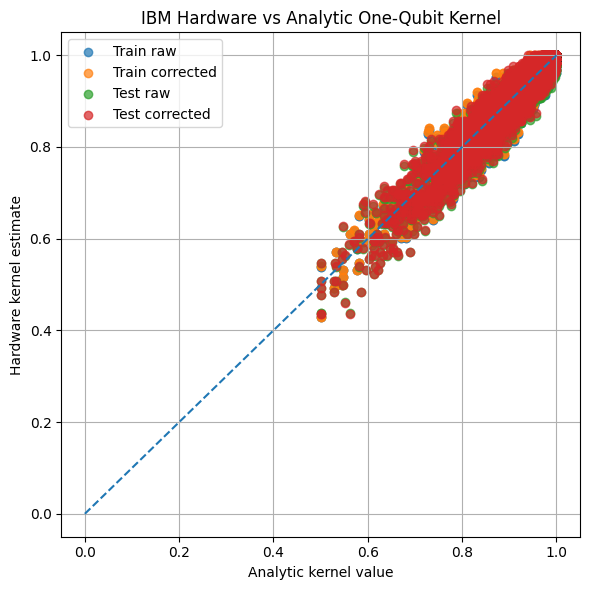

In [16]:
# ============================================================
# 14. COMPARE RAW/CORRECTED HARDWARE KERNELS TO ANALYTIC KERNEL
# ============================================================

def kernel_error_summary(K_hw, K_ref, label):
    abs_error = np.abs(K_hw - K_ref)

    return {
        f"{label}_mean_abs_error": float(np.mean(abs_error)),
        f"{label}_median_abs_error": float(np.median(abs_error)),
        f"{label}_max_abs_error": float(np.max(abs_error)),
    }


kernel_comparison = {}
kernel_comparison.update(kernel_error_summary(K_train_hardware_raw, K_train_analytic, "train_raw"))
kernel_comparison.update(kernel_error_summary(K_train_hardware_corrected, K_train_analytic, "train_corrected"))
kernel_comparison.update(kernel_error_summary(K_test_hardware_raw, K_test_analytic, "test_raw"))
kernel_comparison.update(kernel_error_summary(K_test_hardware_corrected, K_test_analytic, "test_corrected"))

print(json.dumps(kernel_comparison, indent=2))

plt.figure(figsize=(6, 6))

plt.scatter(
    K_train_analytic.flatten(),
    K_train_hardware_raw.flatten(),
    label="Train raw",
    alpha=0.7,
)

plt.scatter(
    K_train_analytic.flatten(),
    K_train_hardware_corrected.flatten(),
    label="Train corrected",
    alpha=0.7,
)

plt.scatter(
    K_test_analytic.flatten(),
    K_test_hardware_raw.flatten(),
    label="Test raw",
    alpha=0.7,
)

plt.scatter(
    K_test_analytic.flatten(),
    K_test_hardware_corrected.flatten(),
    label="Test corrected",
    alpha=0.7,
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Analytic kernel value")
plt.ylabel("Hardware kernel estimate")
plt.title("IBM Hardware vs Analytic One-Qubit Kernel")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Cell 15 — Hardware QSVM subset feasibility check

This cell trains and evaluates precomputed-kernel SVMs using three subset kernels: analytic, raw hardware, and readout-corrected hardware. The comparison quantifies how much finite-shot and hardware noise changed the subset QSVM result relative to the analytic kernel.

This is a feasibility check only. The full diagnostic benchmark remains the simulator-equivalent QSVM result from the simulator notebook.

Final subset QSVM comparison:
{
  "analytic_subset": {
    "label": "analytic_subset",
    "C": 1.0,
    "metrics": {
      "accuracy": 0.7625,
      "precision": 0.7560975609756098,
      "recall": 0.775,
      "specificity": 0.75,
      "f1": 0.7654320987654321,
      "mcc": 0.5251641394443731,
      "confusion_matrix": [
        [
          30,
          10
        ],
        [
          9,
          31
        ]
      ],
      "auc_roc": 0.7890625,
      "balanced_accuracy": 0.7625
    },
    "y_pred": [
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,
      1,


,model,accuracy,balanced_accuracy,precision,recall,specificity,f1,mcc,auc_roc
0,analytic_subset,0.7625,0.7625,0.756098,0.775,0.75,0.765432,0.525164,0.789062
1,hardware_raw,0.7875,0.7875,0.767442,0.825,0.75,0.795181,0.576624,0.787500
2,hardware_corrected,0.7875,0.7875,0.767442,0.825,0.75,0.795181,0.576624,0.789375


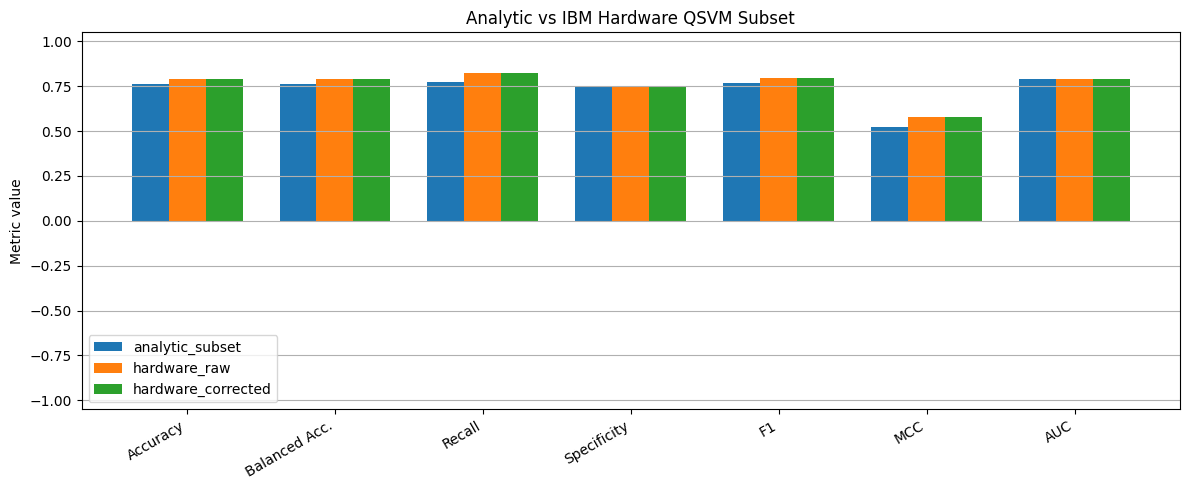

In [17]:
# ============================================================
# 15. FINAL HARDWARE QSVM FEASIBILITY CHECK
# ============================================================

C_HARDWARE_SUBSET = float(simulator_qsvm_results.get("best_C", 1.0))

def evaluate_precomputed_svm(K_train, K_test, y_train, y_test, label):
    clf = SVC(
        kernel="precomputed",
        C=C_HARDWARE_SUBSET,
        class_weight="balanced",
    )

    clf.fit(K_train, y_train)

    y_pred = clf.predict(K_test)
    y_score = clf.decision_function(K_test)

    metrics = compute_binary_metrics(y_test, y_pred, y_score)

    return {
        "label": label,
        "C": C_HARDWARE_SUBSET,
        "metrics": metrics,
        "y_pred": y_pred.tolist(),
        "y_score": y_score.tolist(),
    }


analytic_subset_result = evaluate_precomputed_svm(
    K_train_analytic,
    K_test_analytic,
    y_train_hw,
    y_test_hw,
    label="analytic_subset",
)

hardware_raw_result = evaluate_precomputed_svm(
    K_train_hardware_raw,
    K_test_hardware_raw,
    y_train_hw,
    y_test_hw,
    label="hardware_raw",
)

hardware_corrected_result = evaluate_precomputed_svm(
    K_train_hardware_corrected,
    K_test_hardware_corrected,
    y_train_hw,
    y_test_hw,
    label="hardware_corrected",
)

hardware_subset_metrics = {
    "analytic_subset": analytic_subset_result,
    "hardware_raw": hardware_raw_result,
    "hardware_corrected": hardware_corrected_result,
}

print("Final subset QSVM comparison:")
print(json.dumps(hardware_subset_metrics, indent=2))

comparison_rows = []

for result in [
    analytic_subset_result,
    hardware_raw_result,
    hardware_corrected_result,
]:
    row = {"model": result["label"]}
    row.update(result["metrics"])
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

display(
    comparison_df[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "specificity",
            "f1",
            "mcc",
            "auc_roc",
        ]
    ]
)

metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "recall",
    "specificity",
    "f1",
    "mcc",
    "auc_roc",
]

x = np.arange(len(metrics_to_plot))
width = 0.25

plt.figure(figsize=(12, 5))

for i, row in comparison_df.iterrows():
    plt.bar(
        x + i * width,
        [row[m] if row[m] is not None else 0.0 for m in metrics_to_plot],
        width=width,
        label=row["model"],
    )

plt.xticks(
    x + width,
    ["Accuracy", "Balanced Acc.", "Recall", "Specificity", "F1", "MCC", "AUC"],
    rotation=30,
    ha="right",
)

plt.ylim(-1.05, 1.05)
plt.ylabel("Metric value")
plt.title("Analytic vs IBM Hardware QSVM Subset")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(HW_OUT_DIR / "analytic_vs_hardware_qsvm_subset.png", dpi=300)
plt.show()